# Objective 

Portfolios are a collection of investments an individual owns. This project applies Modern Portfolio Theory to construct and compare portfolios using historical asset return data. The aim is to analyse the trade-off between risk and return, generate the efficient frontier, and identify portfolios such as the minimum variance portfolio and maximum Sharpe ratio portfolio. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

# Collect data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']

data = yf.download(
    tickers,
    start="2018-01-01",
    end="2024-12-31",
    auto_adjust=True
)

prices = data["Close"]
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2018-01-02,40.267075,59.450500,53.188866,180.007385,78.699913
2018-01-03,40.260067,60.209999,54.096321,183.232086,79.066147
2018-01-04,40.447060,60.479500,54.306454,182.894745,79.762062
2018-01-05,40.907585,61.457001,55.026569,185.395126,80.750969
2018-01-08,40.755630,62.343498,55.220848,186.813980,80.833374


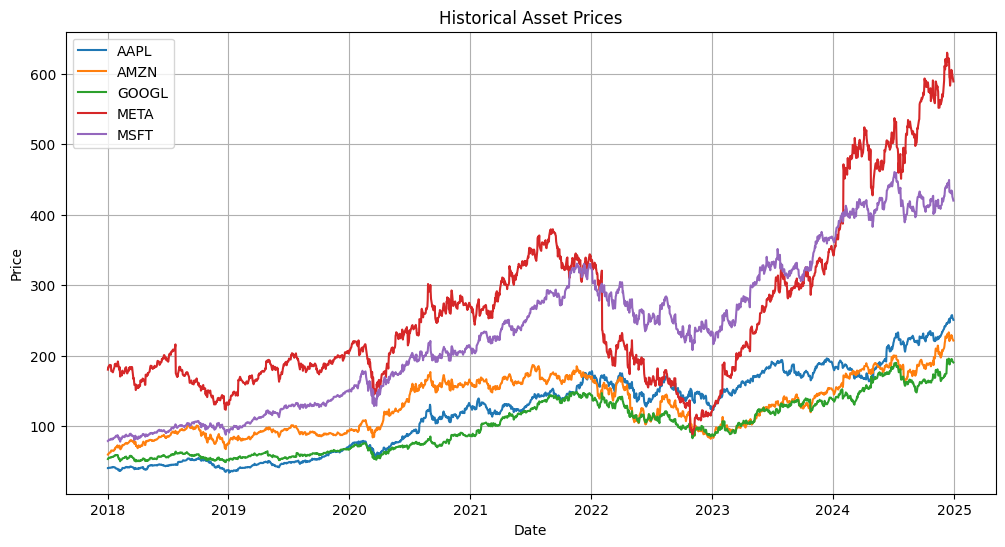

In [3]:
#Plot the price data
plt.figure(figsize=(12, 6))
plt.plot(prices)
plt.title("Historical Asset Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(prices.columns)
plt.grid(True)
plt.show()

In [4]:
#Compute daily returns
returns = prices.pct_change().dropna()
returns.head()
# Annualize returns and covariance
mean_returns = returns.mean() * 252 # Assuming 252 trading days in a year
cov_matrix = returns.cov() * 252 

# Portfolio theory 

For a portfolio with weights $w$, expected return is:

$E[R_p] = w^T \mu$


Portfolio variance is:

$\sigma_p^2 = w^T \Sigma w$


The Sharpe ratio is:

$\frac{E[R_p] - R_f}{\sigma_p}$


The vector, w, contains the proportion of money invested in each asset. The expected return of the portfolio is the weighted average of the expected return of the asset. The portfolio variance measures the risk of the portfolio. $\Sigma$ is the covariance matrix which depicts how volatile each asset is and how they vary together.

# Simulate random portfolios 

In [5]:
# #Initialise number of portfolios and risk free rate
num_portfolios = 10000
risk_free_rate = 0.03


results = []
# Iterate through random portfolios
for _ in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(tickers))
    # Normalize weights to sum to 1
    weights /= np.sum(weights)

    # Calculate portfolio return, volatility, and Sharpe ratio
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    # Store results
    results.append([portfolio_return, portfolio_volatility, sharpe_ratio, weights])

results_df = pd.DataFrame(
    results,
    columns=["Return", "Volatility", "Sharpe", "Weights"]
)

results_df.head()

,Return,Volatility,Sharpe,Weights
0,0.256359,0.278008,0.814216,"[0.004832119208162873, 0.23550134757330346, 0...."
1,0.260820,0.296641,0.778113,"[0.12453164121861081, 0.3533717173152453, 0.11..."
2,0.276933,0.288609,0.855599,"[0.3036626103366112, 0.03948557743856123, 0.08..."
3,0.264719,0.277949,0.844468,"[0.3065417634441209, 0.139512882893827, 0.3307..."
4,0.266789,0.306718,0.772008,"[0.12907406020870363, 0.2344629984282244, 0.02..."


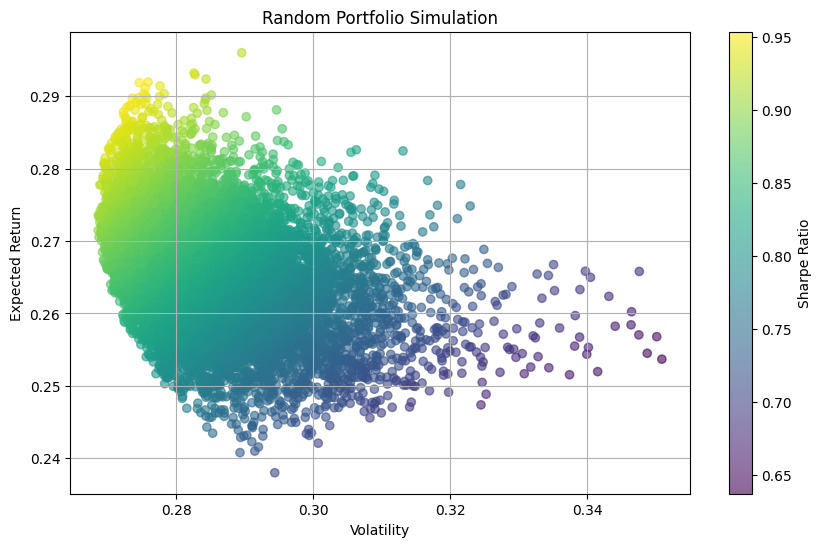

In [6]:
# Plot portfolios

plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Random Portfolio Simulation")
plt.grid(True)
plt.show()

# Maximize Sharpe Ratio

Calculate the weight of each asset that maximizes the Sharpe ratio. This can be done by calculating the negative portfolio and then minimizing it.  The Sequential Least Squares Programming (SLSQP) algorithm is used here to minimize the negative Sharpe ratio. It works by using equal initial weights to calculate the negative sharpe ratio, then iteratively adjusts the weights until a portfolio with lowest negative sharpe ratio is produced while maintaining the constraint that the weights sum to 1. 

In [7]:
# Function to calculate portfolio return and volatility
def portfolio_performance(weights, mean_returns, cov_matrix):
    # Calculate portfolio return and volatility
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility


def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    # Get portfolio return and volatility
    portfolio_return, portfolio_volatility = portfolio_performance(
        weights, mean_returns, cov_matrix
    )
    # Return negative Sharpe ratio
    return -(portfolio_return - risk_free_rate) / portfolio_volatility

# Use equality constraint to ensure weights sum to 1 and bounds to ensure weights are between 0 and 1
constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
bounds = tuple((0, 1) for _ in range(len(tickers)))
# Initial guess (equal weights)
initial_weights = np.array([1 / len(tickers)] * len(tickers))

# Optimize for maximum Sharpe ratio using SLSQP method
max_sharpe_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(mean_returns, cov_matrix, risk_free_rate),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

# Extract optimal weights
max_sharpe_weights = max_sharpe_result.x
# Calculate performance of the optimal portfolio
max_sharpe_return, max_sharpe_volatility = portfolio_performance(
    max_sharpe_weights, mean_returns, cov_matrix
)

max_sharpe_weights

array([5.59711896e-01, 2.68882139e-17, 0.00000000e+00, 0.00000000e+00,
       4.40288104e-01])

# Minimum Variance Portfolio

The weights of investment that will minimize the volatility fo the portfolio will be calculated. This will once again be done using SLSQP with the objective of minimizing portfolio volatility while ensuring all weights sum to 1. 

In [8]:
# Function to calculate portfolio volatility for given weights
def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

# Optimize for minimum volatility using SLSQP method
min_var_result = minimize(
    portfolio_volatility,
    initial_weights,
    args=(mean_returns, cov_matrix),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
# Extract optimal weights
min_var_weights = min_var_result.x
# Calculate performance of the optimal portfolio
min_var_return, min_var_volatility = portfolio_performance(
    min_var_weights, mean_returns, cov_matrix
)

min_var_weights

array([0.30181231, 0.09401625, 0.2538855 , 0.        , 0.35028594])

# Compare Minimum Variance and Maximum ratio portfolios


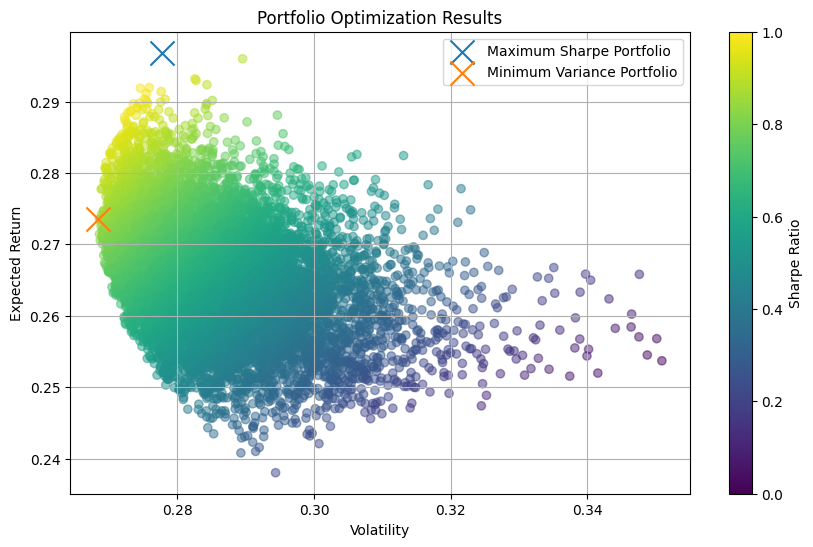

In [20]:
# Create a DataFrame to store the optimal weights for both strategies
weights_df = pd.DataFrame({
    "Asset": tickers,
    "Max Sharpe Weight": max_sharpe_weights,
    "Minimum Variance Weight": min_var_weights
})

plt.figure(figsize=(10, 6))

# Plot all random portfolios
plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.5
)
# Highlight the optimal portfolios for max Sharpe ratio
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="x",
    s=300,
    label="Maximum Sharpe Portfolio"
)
# Highlight the optimal portfolios for minimum variance
plt.scatter(
    min_var_volatility,
    min_var_return,
    marker="x",
    s=300,
    label="Minimum Variance Portfolio"
)

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Portfolio Optimization Results")
plt.legend()
plt.grid(True)
plt.show()

# Efficient Frontiers

Efficient frontiers are the boundaries of the "best" portfolio, that is, a portfolio is on the efficient frontier if for a given level of volatility, it has the highest expected return for each portfolio that can be built. In the code block below, we start with a target return and then minimize the portfolio volatility for the target return using SLSQP. There are two constraints this time for the algorithm, weights must sum to 1 and the target return must be met.

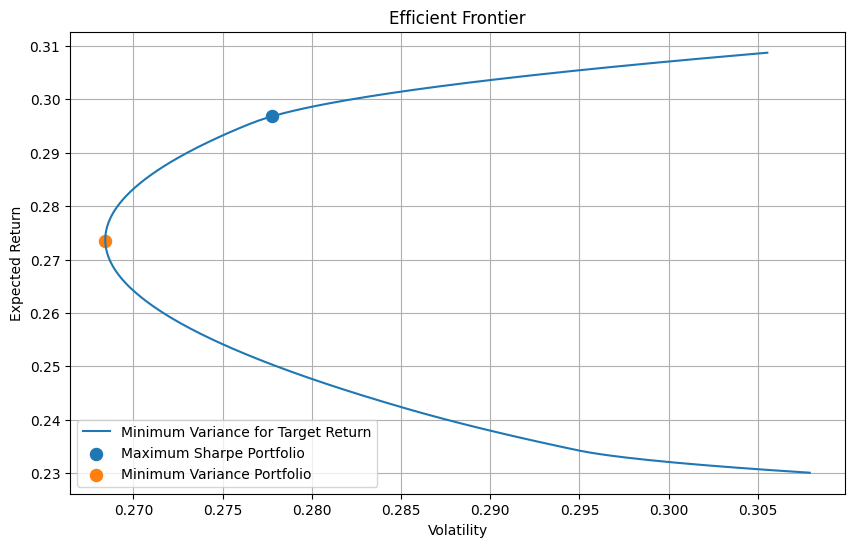

In [18]:
# Generate 500 target returns between the minimum and maximum returns from the random portfolios
target_returns = np.linspace(
    mean_returns.min(),
    mean_returns.max(),
    500
)

# Array to store the efficient frontier volatilities and returns
efficient_volatilities = []
efficient_returns = [] 

#  Iterate through each target return
for target in target_returns:
    # Use equality constraints to ensure weights sum to 1 and the portfolio return equals the target return
    constraints = (
        {"type": "eq", "fun": lambda weights: np.sum(weights) - 1},
        {"type": "eq", "fun": lambda weights, target=target: np.dot(weights, mean_returns) - target}
    )

    # Optimize for minimum volatility using SLSQP method
    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(mean_returns, cov_matrix),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    # Append the resulting volatility and return to the efficient frontier lists if optimization was successful
    if result.success:
        efficient_volatilities.append(result.fun)
        efficient_returns.append(target)

# Plot the efficient frontiers 
plt.figure(figsize=(10, 6))
plt.plot(efficient_volatilities, efficient_returns, label="Minimum Variance for Target Return")
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker=".",
    s=300,
    label="Maximum Sharpe Portfolio"
)
# Highlight the optimal portfolios for minimum variance
plt.scatter(
    min_var_volatility,
    min_var_return,
    marker=".",
    s=300,
    label="Minimum Variance Portfolio"
)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(True)
plt.show()

From the graph above, it can be seen that the left most point is the minimum variance portfolio, which has the lowest volatility. The curve shows the minimum volatility of a portfolio at each expected return. The upper half of the curve is the efficient frontier. The lower half of the curve is the inefficient frontier because there is a portfolio with higher expected return at each volatility. The maximum Sharpe portfolio lies on this efficient frontier and provides the highest risk-adjusted return.

#   Interpretation 

The minimum variance portfolio only minimizes the volatility of the portfolio. It does not consider expected return at all. The maximum Sharpe ratio portfolio takes into account both volatility and expected return. It calculates the portfolio with the highest return per unit of risk. As a result, in this analysis, the maximum Sharpe portfolio accepts  higher volatility, roughly 28%, than the minimum variance portfolio but achieves a higher expected return, making it more attractive for investors seeking efficient risk-return trade-offs.